In [1]:
import sys
import os
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)

In [2]:
%matplotlib inline

In [3]:
import site
import sys

# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)

In [4]:
%load_ext memory_profiler

In [5]:
import warnings
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
from importlib import reload
import mpr_jax
mpr_jax=reload(mpr_jax)

warnings.simplefilter("ignore")

In [6]:
#jax.config.update("jax_enable_x64", True)

In [7]:
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

In [8]:
@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g

    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})

    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]

    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]

    return rv_t, r, v, bold_t, bold_d

In [9]:
def plot(rv_t, r, v, bold_d, bold_t, g, close=True):
    step = 10
    fig, ax = plt.subplots(3, 1, figsize=(12, 6))
    ax[0].plot(rv_t[::step], r[::step, :], lw=0.1)
    ax[1].plot(rv_t[::step], v[::step, :], lw=0.1)
    ax[2].plot(bold_t, bold_d, lw=0.1)
    ax[0].set_ylabel("r")
    ax[1].set_ylabel("v")
    ax[2].set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

In [10]:
nn = 6

weights = nx.to_numpy_array(nx.complete_graph(nn))
params = {"G": 0.25, 
          "weights": weights,
          "t_end": 10000,
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0,
          "seed": 42
          }

In [11]:
nx.complete_graph(nn)

In [12]:
nx.to_numpy_array(nx.complete_graph(nn))
#every region connected to every region (not with itself)

array([[0., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 0.]])

warm up

In [13]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 1.21 seconds


In [14]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 0.61 seconds


In [15]:
jnp.isnan(r).sum()

Array(0, dtype=int32)

In [16]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            62Gi        12Gi       2.7Gi        16Mi        48Gi        50Gi
Swap:             0B          0B          0B


In [2]:
!cat /sys/fs/cgroup/memory.max

2147483648


wrapper took 0.41 seconds


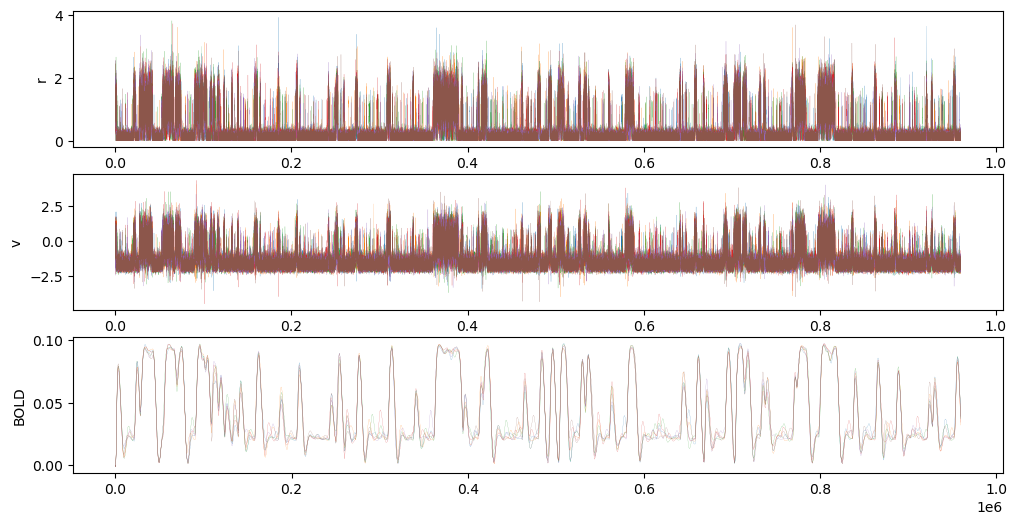

In [18]:
params['t_end'] = 960000
g = 0.33
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

In [19]:
v[len(v)-2971,:]

Array([-1.5969543, -1.6134924, -1.4444994, -1.9180543, -2.0458295,
       -1.8580799], dtype=float32)

In [20]:
len(bold_d)

1920

In [21]:
import numpy as np
import utils
datapath = utils.DATA_ROOT
weights = np.loadtxt(datapath+"/weights.txt", delimiter=None)

In [22]:
nn = len(weights)
params = {"G": 0.25, 
          "weights": weights/np.max(weights),
          "t_end": 10000,
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0,
          "seed": 42
          }

In [23]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 0.63 seconds


In [24]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 0.29 seconds


In [25]:
params['t_end'] = 960000
g = 0.0
rv_t, r, v, bold_t, bold_d = wrapper(g, params)

wrapper took 0.43 seconds


In [26]:
#%%memit
#plot(rv_t, r, v, bold_d, bold_t, g)
bold_G0 = bold_d

In [ ]:
%%memit
params['t_end'] = 960000
g = 0.5
rv_t, r, v, bold_t, bold_d = wrapper(g, params)

In [ ]:
#%%memit
#plot(rv_t, r, v, bold_d, bold_t, g)
bold_G05 = bold_d

In [ ]:
%%memit
params['t_end'] = 960000
g = 0.7
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
#plot(rv_t, r, v, bold_d, bold_t, g)
bold_G07 = bold_d 

In [ ]:
bold_G0_T = bold_G0.T     # shape: (88, 60)
bold_G05_T = bold_G05.T
bold_G07_T = bold_G07.T

In [ ]:
from matplotlib import pyplot as plt
from FCD import *

# Adjust parameters due to small time series
wwidth = 20  # must be < 60
maxNwindows = 10
olap = 0.5

FCD_G0, FCvec_G0, _ = extract_FCD(bold_G0_T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
FCD_G05, FCvec_G05, _ = extract_FCD(bold_G05_T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
FCD_G07, FCvec_G07, _ = extract_FCD(bold_G07_T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)

# Static FC (over full time series)
FC_G0 = np.corrcoef(bold_G0_T)
FC_G05 = np.corrcoef(bold_G05_T)
FC_G07 = np.corrcoef(bold_G07_T)


In [ ]:
def plot_fc_fcd(bold, FC, FCD, label='G=?'):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3))
    axs[0].plot(bold)
    axs[0].set_title(f'BOLD\n{label}')
    axs[1].imshow(FC, vmin=-1, vmax=1, cmap='hot')
    axs[1].set_title('FC')
    axs[2].imshow(FCD, vmin=0, vmax=1, cmap='hot')
    axs[2].set_title('FCD')
    plt.tight_layout()
    plt.show()

plot_fc_fcd(bold_G0, FC_G0, FCD_G0, label='G=0.0')
plot_fc_fcd(bold_G05, FC_G05, FCD_G05, label='G=0.5')
plot_fc_fcd(bold_G07, FC_G07, FCD_G07, label='G=0.7')

In [ ]:
np.shape(bold_d)

In [ ]:
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(8, 8))
mask = np.zeros_like(weights, dtype=bool)
mask[np.triu_indices_from(mask)] = False
#cmap = sns.diverging_palette(220, 10, as_cmap=True)
cmap='RdGy'
sns.heatmap(weights, mask=mask, cmap=cmap, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title(' Human Structural Connectivity (SC) Matrix ',fontsize=16)
plt.ylabel('#Regions', fontsize=18.0)
plt.xlabel('#Regions', fontsize=18.0)
plt.xticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
plt.yticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
#plt.gca().invert_xaxis()
plt.tight_layout()
resultspath = utils.RESULTS_ROOT
#plt.savefig(os.path.join(resultspath,"SCmatrix.png"), dpi=800)
#plt.savefig(os.path.join(resultspath,"SCmatrix.eps"), dpi=800)
plt.show()